# Analiza widma energii cząstek alpha
Analiza widma alpha, identyfikacja linii widmowych.

In [79]:
# Prosta (y = ax + b) - wartości parametrów otrzymane z kalibracji energetycznej alpha
a = 0.00430
b = 0.05266

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [81]:
def load_lst(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Znajdź linię, po której zaczynają się dane (pod $DATA:)
    start_idx = 0
    for i, line in enumerate(lines):
        if '$DATA:' in line:
            start_idx = i + 2  # Dane zaczynają się dwie linie niżej
            break
            
    # Wczytaj dane (kanał i liczba zliczeń)
    # Dane są rozdzielone spacjami
    data = pd.read_csv(filename, skiprows=start_idx, sep=r'\s+', 
                       header=None, names=['channel', 'counts'], nrows=8192)
    return data

### Znalezienie pików alpha

In [82]:
filename = 'dane/pomiar_alpha.lst'
df = load_lst(filename)
    
# 2. Kalibracja energetyczna: E = a * x + b
df['energy'] = df['channel'] * a + b

# 3. Znajdowanie pików
# height=10: ignorujemy szum tła poniżej 10 zliczeń
# prominence=5: pik musi wyróżniać się z otoczenia o co najmniej 5 zliczeń
peaks_indices, _ = find_peaks(df['counts'], height=11, prominence=7, width=2)

# Przygotowanie danych pików
peak_energies = df.loc[peaks_indices, 'energy']
peak_counts = df.loc[peaks_indices, 'counts']
peak_channels = df.loc[peaks_indices, 'channel']

# 4. Wypisanie listy pików
print(f"\n{'='*55}")
print(f"E = {a}*ch + {b}")
print(f"{'='*55}")
print(f"{'Nr':<4} | {'Kanał':<8} | {'Energia [MeV]':<15} | {'Zliczenia':<10}")
print(f"{'-'*55}")

for i, (ch, en, cnt) in enumerate(zip(peak_channels, peak_energies, peak_counts)):
    print(f"{i+1:<4} | {int(ch):<8} | {en:<15.4f} | {int(cnt):<10}")
print(f"{'='*55}\n")


E = 0.0043*ch + 0.05266
Nr   | Kanał    | Energia [MeV]   | Zliczenia 
-------------------------------------------------------
1    | 111      | 0.5300          | 12        
2    | 971      | 4.2280          | 12        
3    | 1009     | 4.3914          | 74        
4    | 1029     | 4.4774          | 19        
5    | 1096     | 4.7655          | 2503      
6    | 1185     | 5.1482          | 186       
7    | 1263     | 5.4836          | 53        



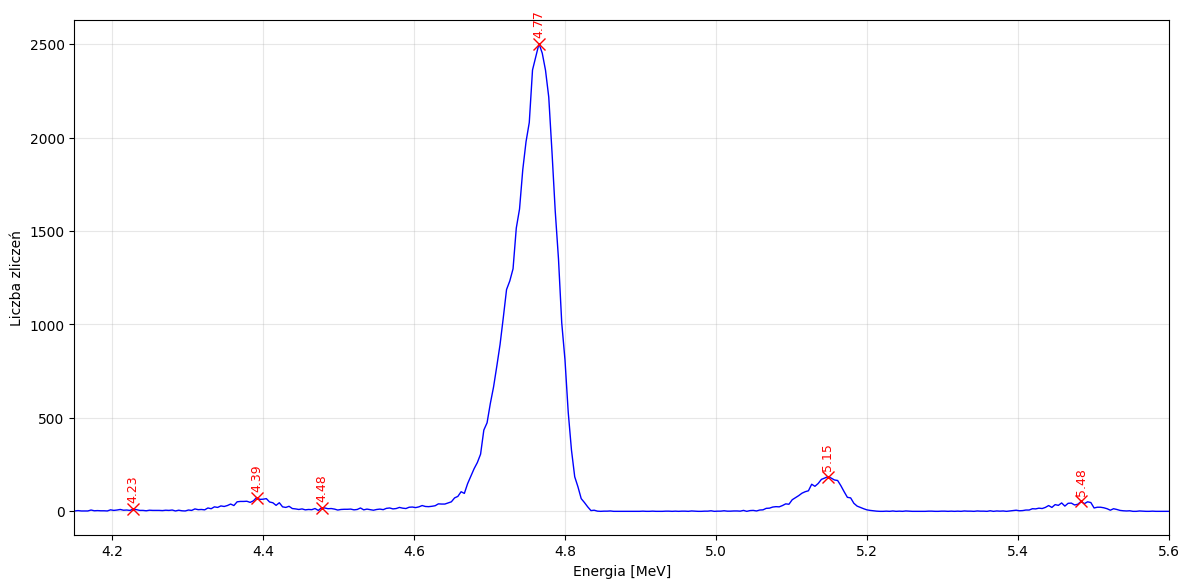

In [83]:
plt.figure(figsize=(12, 6))
plt.plot(df['energy'], df['counts'], label='Widmo', color='blue', linewidth=1)

# Zaznaczanie pików na wykresie
plt.plot(peak_energies, peak_counts, "rx", label='Znalezione piki', markersize=8)

# Podpisywanie pików
for en, cnt in zip(peak_energies, peak_counts):
    if en>4:
        plt.text(en, cnt + (df['counts'].max()*0.02), f"{en:.2f}", 
                    ha='center', fontsize=9, rotation=90, color='red')

plt.xlabel("Energia [MeV]")
plt.ylabel("Liczba zliczeń")
#plt.title(f"Widmo promieniowania (a={a}, b={b})")
#plt.legend()
plt.xlim(4.15, 5.6)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

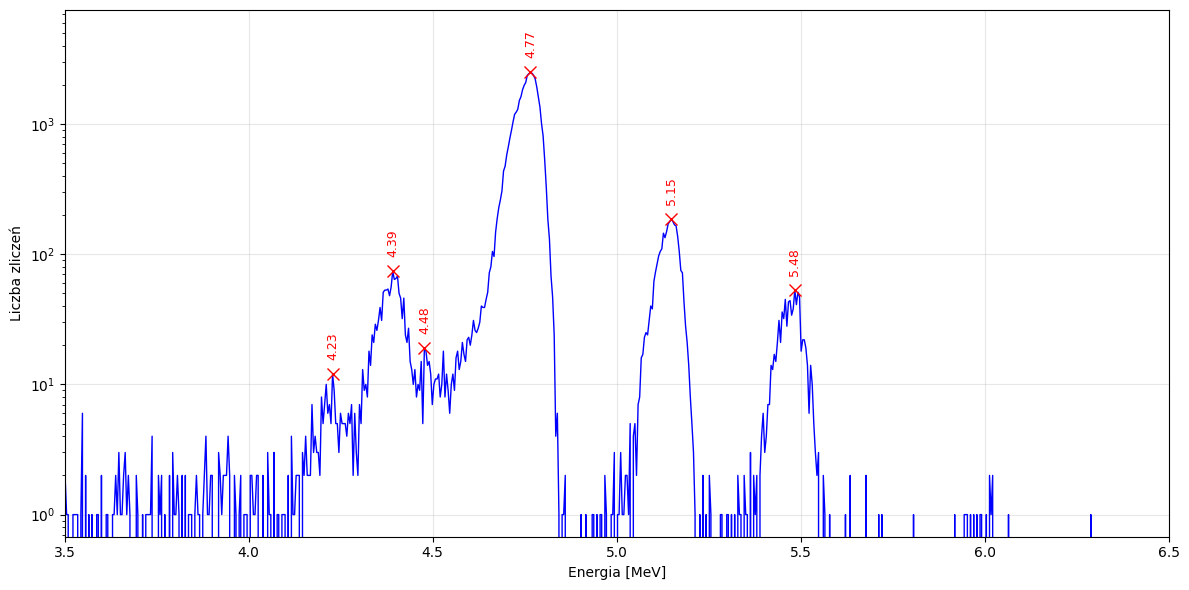

In [89]:
plt.figure(figsize=(12, 6))
plt.plot(df['energy'], df['counts'], label='Widmo', color='blue', linewidth=1)

# Zaznaczanie pików na wykresie
plt.plot(peak_energies, peak_counts, "rx", label='Znalezione piki', markersize=8)
plt.yscale('log')
# Podpisywanie pików
for en, cnt in zip(peak_energies, peak_counts):
    if en>4:
        plt.annotate(f"{en:.2f}", 
                            xy=(en, cnt),                # Gdzie wskazuje (czubek piku)
                            xytext=(0, 10),              # Przesunięcie tekstu: 0 w bok, 10 punktów w górę
                            textcoords='offset points',  # Ważne: system współrzędnych przesunięcia
                            ha='center', 
                            va='bottom',                 # Wyrównanie do dołu (tekst "siedzi" na punkcie)
                            fontsize=9, 
                            rotation=90, 
                            color='red')

plt.xlabel("Energia [MeV]")
plt.ylabel("Liczba zliczeń")
#plt.title(f"Widmo promieniowania (a={a}, b={b})")
#plt.legend()

plt.xlim(3.5, 6.5)
plt.ylim(top=df['counts'].max() * 3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [85]:
# 1. Baza danych energii alfa (Główne linie w MeV)
# Źródło: NNDC (National Nuclear Data Center)
# Uwaga: Podaję główne linie (największe prawdopodobieństwo)
known_isotopes = {
    # --- SZEREG URANOWY (4n+2) ---
    # Główny składnik uranu naturalnego (99.27%).
    # U-238 rozpada się do U-234, więc U-234 jest częścią tego szeregu.
    'U-238':  [4.198, 4.151],      # Głowa szeregu
    'U-234':  [4.774, 4.722],      # Potomek U-238 (często w równowadze wiekowej)
    'Th-230': [4.687, 4.620],      # Córka U-234 (Tor-230)
    'Ra-226': [4.784, 4.601],      # Córka Th-230 (Rad-226)
    'Rn-222': [5.489],             # Radon (gaz), córka Ra-226
    'Po-218': [6.002],             # Córka Radonu (krótki czas życia)
    'Po-214': [7.687],             # Córka bizmutu (bardzo wysoka energia!)
    'Po-210': [5.304],             # Końcówka szeregu (Polon-210)

    # --- SZEREG AKTYNOWY (4n+3) ---
    # Pochodzi od U-235 (ok. 0.72% w naturze). 
    # Mniej aktywny, ale ma wiele linii alfa.
    'U-235':  [4.398, 4.365, 4.59, 4.21], # Głowa szeregu aktynowego
    'Pa-231': [5.013, 5.029, 4.95],       # Protaktyn (córka U-235) - ważny izotop!
    'Th-227': [6.038, 5.978, 5.757],      # Tor-227
    'Ra-223': [5.716, 5.607, 5.75],       # Rad-223
    'Rn-219': [6.819, 6.55],              # Aktynon (gaz)
    'Bi-211': [6.623, 6.278],             # Bizmut-211
    'Po-215': [7.386],                    # Polon-215

    # --- INNE (Sztuczne / Znaczniki) ---
    # Warto mieć w bazie, jeśli próbka jest "podejrzana" lub używano znacznika
    'Pu-239': [5.156, 5.144],      # Pluton-239 (pasuje do Twojego piku 5.14!)
}

# Twoje znalezione piki (przykład z poprzedniego kontekstu)
# peak_energies = [...] 

# 2. Funkcja do identyfikacji
def identify_peaks(found_energies, library, tolerance=0.05):
    """
    found_energies: lista znalezionych energii pików
    library: słownik znanych izotopów
    tolerance: +/- MeV (np. 0.05 MeV = 50 keV)
    """
    print(f"{'Znaleziony Pik':<15} | {'Pasujący Izotop':<15} | {'Energia Ref.':<15} | {'Różnica':<10}")
    print("-" * 65)
    
    for peak in found_energies:
        match_found = False
        for isotope, lines in library.items():
            for ref_energy in lines:
                if abs(peak - ref_energy) <= tolerance:
                    diff = peak - ref_energy
                    print(f"{peak:<15.4f} | {isotope:<15} | {ref_energy:<15.3f} | {diff:+.4f}")
                    match_found = True
        
        if not match_found:
            print(f"{peak:<15.4f} | {'???':<15} | {'-':<15} | {'-'}")

# Uruchomienie sprawdzenia (przyjęto tolerancję 50 keV)
identify_peaks(peak_energies, known_isotopes, tolerance=0.05)

Znaleziony Pik  | Pasujący Izotop | Energia Ref.    | Różnica   
-----------------------------------------------------------------
0.5300          | ???             | -               | -
4.2280          | U-238           | 4.198           | +0.0300
4.2280          | U-235           | 4.210           | +0.0180
4.3914          | U-235           | 4.398           | -0.0066
4.3914          | U-235           | 4.365           | +0.0264
4.4774          | ???             | -               | -
4.7655          | U-234           | 4.774           | -0.0085
4.7655          | U-234           | 4.722           | +0.0435
4.7655          | Ra-226          | 4.784           | -0.0185
5.1482          | Pu-239          | 5.156           | -0.0078
5.1482          | Pu-239          | 5.144           | +0.0042
5.4836          | Rn-222          | 5.489           | -0.0054


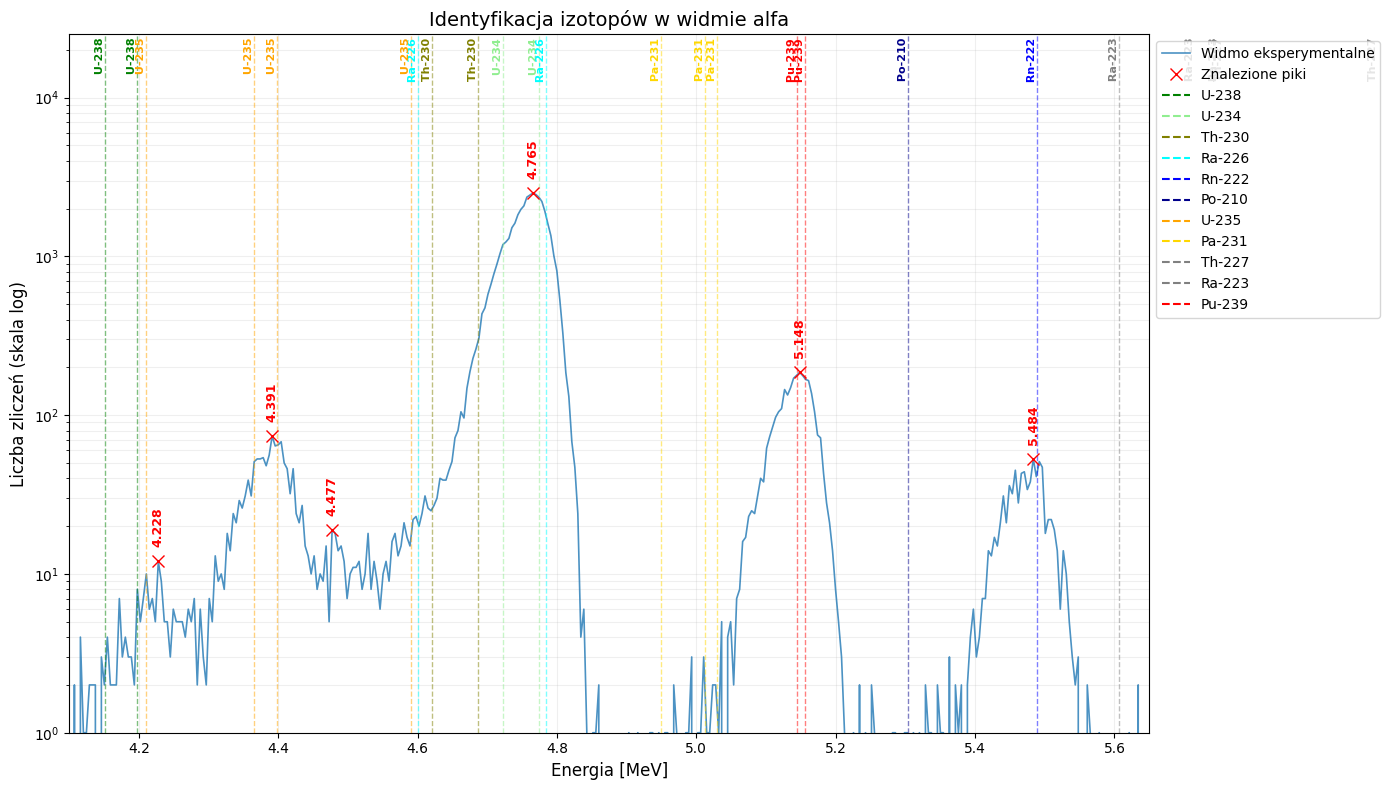

In [88]:
import matplotlib.pyplot as plt
import numpy as np  # Upewniamy się, że numpy jest zaimportowany

# --- A. Konfiguracja wykresu ---
plt.figure(figsize=(14, 8))

# Rysowanie widma
plt.plot(df['energy'], df['counts'], label='Widmo eksperymentalne', 
         color='#1f77b4', linewidth=1.2, alpha=0.8)

# --- B. NAPRAWA BŁĘDU TYPÓW (KeyError) ---
# Konwertujemy dane pików na czyste tablice NumPy, aby indeksy szły od 0 do N
peak_energies_arr = np.array(peak_energies)
peak_counts_arr = np.array(peak_counts)

# --- C. Filtrowanie i rysowanie pików ---
# Teraz operujemy na tablicach _arr, które nie mają problemów z indeksami
valid_peaks_indices = [i for i, en in enumerate(peak_energies_arr) if en > 1.0]
valid_energies = peak_energies_arr[valid_peaks_indices]
valid_counts = peak_counts_arr[valid_peaks_indices]

plt.plot(valid_energies, valid_counts, "rx", label='Znalezione piki', markersize=8, zorder=5)

# --- D. Ustawienie limitów OSI ---
plt.xlim(4.1, 5.65) 
plt.yscale('log')
y_max_limit = df['counts'].max() * 10 
plt.ylim(bottom=1, top=y_max_limit)

# --- E. Podpisywanie pików ---
for en, cnt in zip(valid_energies, valid_counts):
    plt.annotate(f"{en:.3f}", 
                 xy=(en, cnt), 
                 xytext=(0, 10), 
                 textcoords='offset points', 
                 ha='center', va='bottom', 
                 fontsize=9, rotation=90, color='red', weight='bold')

# --- F. Rysowanie linii teoretycznych ---
# (Tutaj wklejam Twój słownik i logikę z poprzedniego kroku)
iso_colors = {
    'U-238': 'green', 'U-234': 'lightgreen', 'Th-230': 'olive',
    'Ra-226': 'cyan', 'Rn-222': 'blue', 'Po-210': 'darkblue',
    'U-235': 'orange', 'Pa-231': 'gold',
    'Pu-239': 'red'
}

used_labels = set()
for iso, lines in known_isotopes.items():
    color = iso_colors.get(iso, 'gray')
    for ref_energy in lines:
        if 3.5 <= ref_energy <= 6.0:
            plt.axvline(x=ref_energy, color=color, linestyle='--', alpha=0.5, linewidth=1)
            plt.text(ref_energy, y_max_limit * 0.95, f" {iso}", 
                     color=color, rotation=90, ha='right', va='top', fontsize=8, weight='bold')
            if iso not in used_labels:
                plt.plot([], [], color=color, linestyle='--', label=f'{iso}')
                used_labels.add(iso)

# --- G. Kosmetyka końcowa ---
plt.xlabel("Energia [MeV]", fontsize=12)
plt.ylabel("Liczba zliczeń (skala log)", fontsize=12)
plt.title("Identyfikacja izotopów w widmie alfa", fontsize=14)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()

plt.show()